<a href="https://colab.research.google.com/github/zakasaleem35-jpg/neurofive-ml-track/blob/main/titanic_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import numpy as np
df=pd.read_csv('train.csv')

df.shape


(891, 12)

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## Data Story
## Dataset: Titanic (train.csv)

- The dataset contains **891 rows** and **12 columns**, where each row represents one passenger.
- **Three columns have missing values:** `Age` (177 missing), `Cabin` (687 missing — the highest), and `Embarked` (2 missing).
- **Numerical columns:** PassengerId, Survived, Pclass, Age, SibSp, Parch, and Fare.
- **Categorical columns:** Name, Sex, Ticket, Cabin, and Embarked.
- `Cabin` has too many missing values (about 77%), so it may need to be dropped, while `Age` and `Embarked` can be filled during cleaning.
- Overall, the data is fairly clean and ready for further analysis after handling the missing values.

# Week 1 · Task 2: Data Cleaning & Visualization

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df = df.drop(columns=['Cabin'])

df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Missing Value Handling

I filled `Age` with the median instead of the mean, since the median is more
robust to outliers and Age has a slightly skewed distribution. `Embarked` had
only 2 missing values, so I filled them with the mode (the most frequent port).
`Cabin` was missing in ~77% of rows — too sparse to reliably impute, so I
dropped the column entirely rather than introduce noise into the dataset.

## Outlier Detection

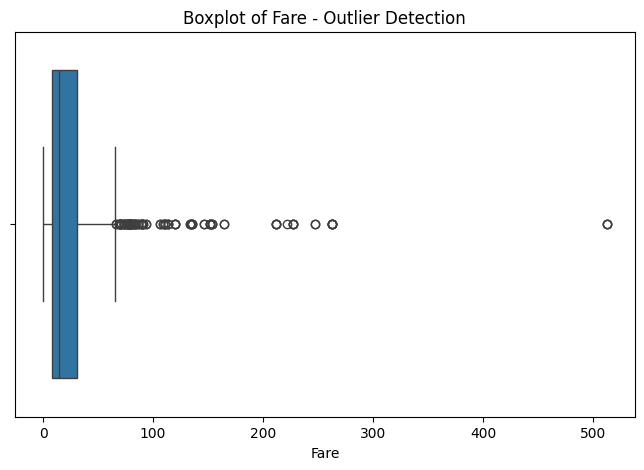

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Fare'])
plt.title('Boxplot of Fare - Outlier Detection')
plt.show()

The Fare boxplot shows several outliers on the higher end — a few passengers
paid extremely high fares (above 200), while most paid under 100. These are
likely first-class passengers, so they are genuine values rather than data errors.

## Visualizations

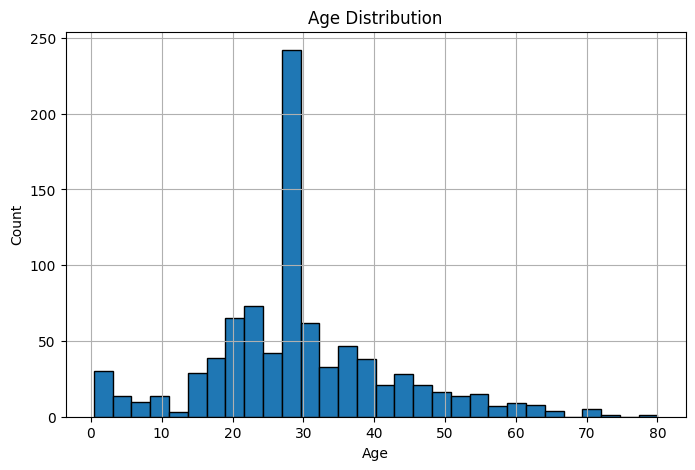

In [14]:
# Histogram(Age)
plt.figure(figsize=(8,5))
df['Age'].hist(bins=30, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

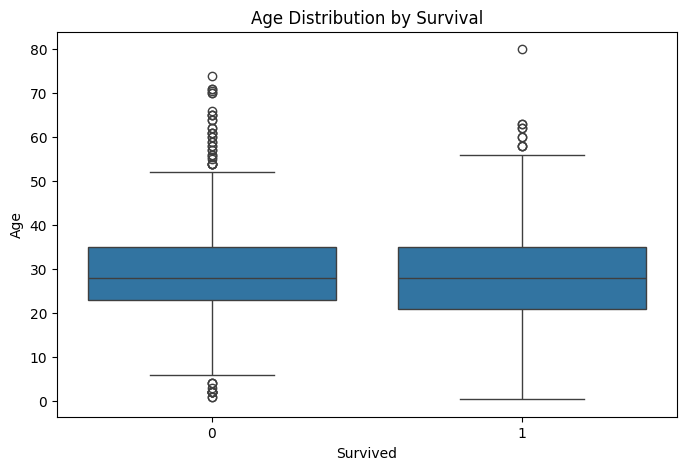

In [15]:
# Boxplot(Age by Survival)
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Survived'], y=df['Age'])
plt.title('Age Distribution by Survival')
plt.show()

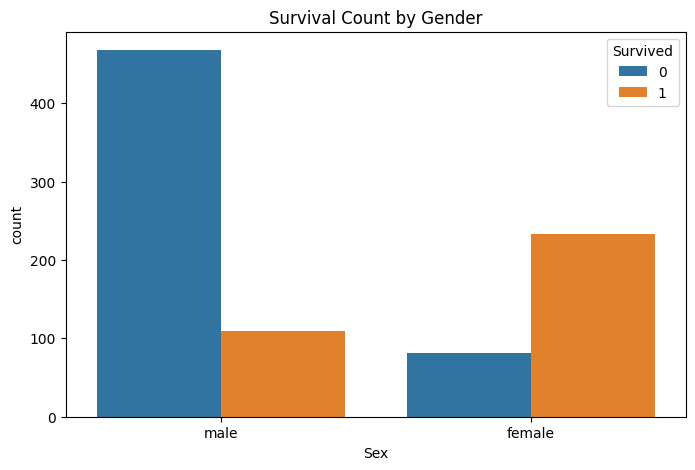

In [16]:
# Bar chart(Survival Count by Gender)
plt.figure(figsize=(8,5))
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Gender')
plt.show()

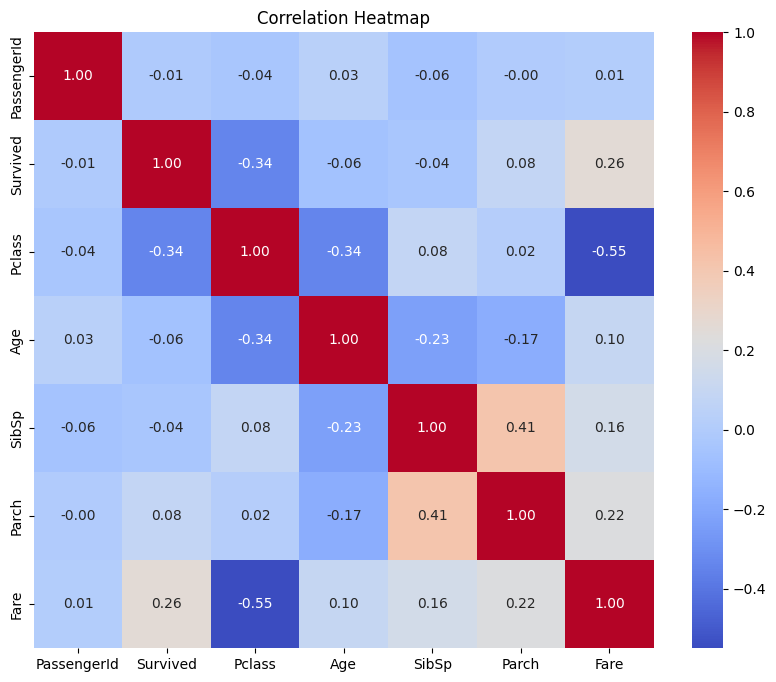

In [17]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Which Feature Affects Survival Most?

Based on the visualizations, **`Sex` most strongly affects survival**. The
gender bar chart shows a dramatic gap: most male passengers did not survive
(around 468 died vs 109 survived), while the majority of female passengers
survived (about 233 survived vs 81 died). This reflects the "women and
children first" evacuation protocol.

Among the numerical features in the correlation heatmap, `Pclass` has the
strongest relationship with survival (correlation of -0.34), passengers in
higher classes (1st class) were more likely to survive. `Fare` also shows a
positive correlation (0.26), meaning passengers who paid more had better
survival chances, which makes sense since they were usually in first class.
`Age` had almost no correlation (-0.06), so it was not a major factor.